   CustomerID Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1   Male   19                 109                      36
1           2   Male   32                  32                      95
2           3   Male   61                 109                      70
3           4   Male   55                  69                       5
4           5   Male   23                  42                      30
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                    0
A

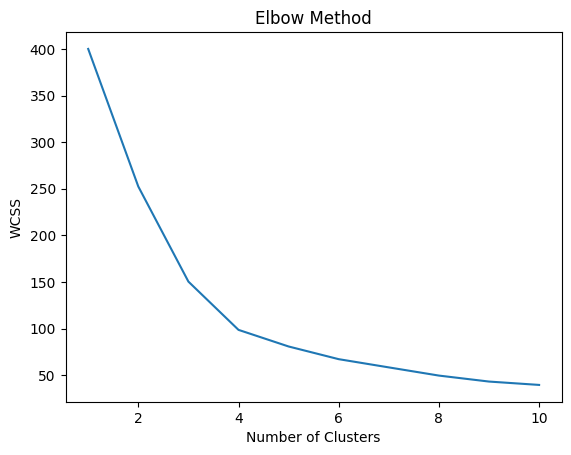

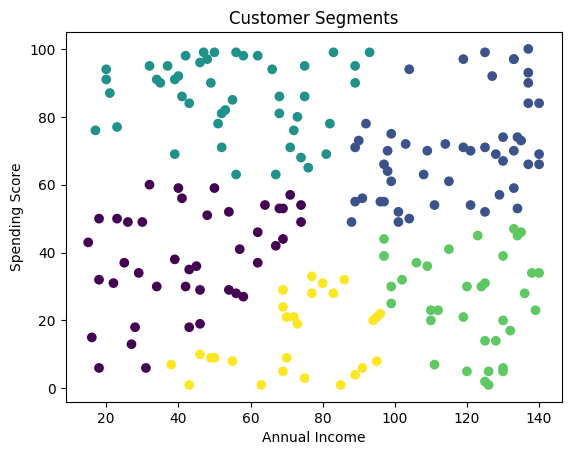

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0        107.523810  42.333333           43.666667               38.547619
1        105.980000  44.520000          116.640000               70.260000
2         92.891304  43.521739           54.782609               85.804348
3         95.542857  43.171429          121.000000               25.685714
4         98.814815  42.444444           72.555556               15.185185


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
data = pd.read_csv("C:/Users/lokpa/OneDrive/Desktop/loki/Mall_Customers.csv")
print(data.head())
print(data.info())
print(data.isnull().sum())
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()
kmeans = KMeans(n_clusters=5)
y_pred = kmeans.fit_predict(X_scaled)
data['Cluster'] = y_pred
plt.scatter(data['Annual Income (k$)'],
            data['Spending Score (1-100)'],
            c=data['Cluster'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()
print(data.groupby('Cluster').mean(numeric_only=True))
